In [1]:
import os
import json
import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader

In [2]:
# ============================================================
# 1. DEVICE
# ============================================================

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("=" * 60)
print("DEVICE:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print("CUDA:", torch.version.cuda)

print("=" * 60)


DEVICE: cuda
GPU: NVIDIA GeForce RTX 3050 6GB Laptop GPU
CUDA: 12.8


In [4]:
import os

BASE_DIR = r"F:\Capstone project\module 1 Tree Check"

TRAIN_DIR = os.path.join(
    BASE_DIR, "dataset", "processed", "train"
)

VAL_DIR = os.path.join(
    BASE_DIR, "dataset", "processed", "val"
)

TEST_DIR = os.path.join(
    BASE_DIR, "dataset", "processed", "test"
)

MODEL_DIR = os.path.join(
    BASE_DIR, "models"
)

OUTPUT_DIR = os.path.join(
    BASE_DIR, "outputs"
)

os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(OUTPUT_DIR, exist_ok=True)

print("Train:", TRAIN_DIR)
print("Validation:", VAL_DIR)
print("Test:", TEST_DIR)

Train: F:\Capstone project\module 1 Tree Check\dataset\processed\train
Validation: F:\Capstone project\module 1 Tree Check\dataset\processed\val
Test: F:\Capstone project\module 1 Tree Check\dataset\processed\test


In [5]:
import os

folders = [
    TRAIN_DIR,
    VAL_DIR,
    TEST_DIR
]

for folder in folders:
    print("\n", folder)

    for class_name in ["tree", "not_tree"]:
        class_path = os.path.join(folder, class_name)

        if os.path.exists(class_path):
            images = [
                f for f in os.listdir(class_path)
                if f.lower().endswith(
                    (".jpg", ".jpeg", ".png", ".webp")
                )
            ]

            print(
                class_name,
                ":", len(images), "images"
            )

        else:
            print(
                class_name,
                ": FOLDER NOT FOUND"
            )


 F:\Capstone project\module 1 Tree Check\dataset\processed\train
tree : 2099 images
not_tree : 2099 images

 F:\Capstone project\module 1 Tree Check\dataset\processed\val
tree : 449 images
not_tree : 449 images

 F:\Capstone project\module 1 Tree Check\dataset\processed\test
tree : 451 images
not_tree : 451 images


In [6]:
# ============================================================
# 3. IMPORT LIBRARIES
# ============================================================

import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

PyTorch version: 2.11.0+cu128
CUDA available: True


In [7]:
# ============================================================
# 4. DEVICE
# ============================================================

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Using device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Using device: cuda
GPU: NVIDIA GeForce RTX 3050 6GB Laptop GPU


In [8]:
# ============================================================
# 5. IMAGE TRANSFORMS
# ============================================================

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),

    transforms.RandomHorizontalFlip(),

    transforms.RandomRotation(10),

    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])


val_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

print("Transforms created successfully")

Transforms created successfully


In [9]:
# ============================================================
# 6. LOAD DATASET
# ============================================================

train_dataset = datasets.ImageFolder(
    TRAIN_DIR,
    transform=train_transform
)

val_dataset = datasets.ImageFolder(
    VAL_DIR,
    transform=val_test_transform
)

test_dataset = datasets.ImageFolder(
    TEST_DIR,
    transform=val_test_transform
)


print("Classes:", train_dataset.classes)

print("Class mapping:", train_dataset.class_to_idx)

print()
print("Training images  :", len(train_dataset))
print("Validation images:", len(val_dataset))
print("Test images      :", len(test_dataset))

Classes: ['not_tree', 'tree']
Class mapping: {'not_tree': 0, 'tree': 1}

Training images  : 4198
Validation images: 898
Test images      : 902


In [10]:
# ============================================================
# 7. DATALOADERS
# ============================================================

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=0,
    pin_memory=torch.cuda.is_available()
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=0,
    pin_memory=torch.cuda.is_available()
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=0,
    pin_memory=torch.cuda.is_available()
)

print("DataLoaders created successfully")

DataLoaders created successfully


In [11]:
# ============================================================
# 8. CHECK DATA
# ============================================================

images, labels = next(iter(train_loader))

print("Image shape :", images.shape)
print("Label shape :", labels.shape)
print("Labels      :", labels[:10])

Image shape : torch.Size([32, 3, 224, 224])
Label shape : torch.Size([32])
Labels      : tensor([0, 1, 0, 1, 1, 0, 1, 1, 0, 0])


In [12]:
# ============================================================
# 9. RESNET-18
# ============================================================

print("Loading pretrained ResNet-18...")

weights = models.ResNet18_Weights.DEFAULT

model = models.resnet18(
    weights=weights
)

# Replace final classification layer
model.fc = nn.Linear(
    model.fc.in_features,
    2
)

model = model.to(device)

print(model.fc)

Loading pretrained ResNet-18...
Linear(in_features=512, out_features=2, bias=True)


In [13]:
# ============================================================
# 8. LOSS FUNCTION
# ============================================================

criterion = nn.CrossEntropyLoss()


In [14]:
# ============================================================
# 9. OPTIMIZER
# ============================================================

optimizer = optim.AdamW(
    model.parameters(),
    lr=0.0001,
    weight_decay=0.0001
)

In [15]:
# ============================================================
# 10. TRAINING SETTINGS
# ============================================================

epochs = 10

best_val_accuracy = 0.0

history = {
    "train_loss": [],
    "train_accuracy": [],
    "val_loss": [],
    "val_accuracy": []
}

In [16]:
# ============================================================
# 10. TRAINING SETTINGS
# ============================================================

epochs = 10

best_val_accuracy = 0.0

history = {
    "train_loss": [],
    "train_accuracy": [],
    "val_loss": [],
    "val_accuracy": []
}


# ============================================================
# 11. TRAINING LOOP
# ============================================================

for epoch in range(epochs):

    print("\n" + "=" * 60)
    print(f"Epoch [{epoch + 1}/{epochs}]")
    print("=" * 60)

    # --------------------------------------------------------
    # TRAIN
    # --------------------------------------------------------

    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:

        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        # Clear gradients
        optimizer.zero_grad()

        # Forward pass
        outputs = model(images)

        # Calculate loss
        loss = criterion(outputs, labels)

        # Backpropagation
        loss.backward()

        # Update weights
        optimizer.step()

        running_loss += loss.item()

        _, predictions = torch.max(outputs, 1)

        total += labels.size(0)

        correct += (
            predictions == labels
        ).sum().item()

    train_loss = running_loss / len(train_loader)

    train_accuracy = (
        100.0 * correct / total
    )


    # --------------------------------------------------------
    # VALIDATION
    # --------------------------------------------------------

    model.eval()

    val_running_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(
                device,
                non_blocking=True
            )

            labels = labels.to(
                device,
                non_blocking=True
            )

            outputs = model(images)

            loss = criterion(
                outputs,
                labels
            )

            val_running_loss += loss.item()

            _, predictions = torch.max(
                outputs,
                1
            )

            val_total += labels.size(0)

            val_correct += (
                predictions == labels
            ).sum().item()

    val_loss = (
        val_running_loss /
        len(val_loader)
    )

    val_accuracy = (
        100.0 * val_correct / val_total
    )


    # --------------------------------------------------------
    # SAVE HISTORY
    # --------------------------------------------------------

    history["train_loss"].append(
        train_loss
    )

    history["train_accuracy"].append(
        train_accuracy
    )

    history["val_loss"].append(
        val_loss
    )

    history["val_accuracy"].append(
        val_accuracy
    )


    # --------------------------------------------------------
    # PRINT RESULTS
    # --------------------------------------------------------

    print(
        f"Train Loss      : {train_loss:.4f}"
    )

    print(
        f"Train Accuracy  : {train_accuracy:.2f}%"
    )

    print(
        f"Val Loss        : {val_loss:.4f}"
    )

    print(
        f"Val Accuracy    : {val_accuracy:.2f}%"
    )


    # --------------------------------------------------------
    # SAVE BEST MODEL
    # --------------------------------------------------------

    if val_accuracy > best_val_accuracy:

        best_val_accuracy = val_accuracy

        model_path = os.path.join(
            MODEL_DIR,
            "tree_detector_resnet18.pth"
        )

        torch.save(
            model.state_dict(),
            model_path
        )

        print(
            f"\nBest model saved!"
        )

        print(
            f"Validation Accuracy: "
            f"{best_val_accuracy:.2f}%"
        )



Epoch [1/10]
Train Loss      : 0.2867
Train Accuracy  : 87.64%
Val Loss        : 0.2343
Val Accuracy    : 90.53%

Best model saved!
Validation Accuracy: 90.53%

Epoch [2/10]
Train Loss      : 0.1593
Train Accuracy  : 93.71%
Val Loss        : 0.2553
Val Accuracy    : 89.87%

Epoch [3/10]
Train Loss      : 0.1173
Train Accuracy  : 95.78%
Val Loss        : 0.2184
Val Accuracy    : 91.76%

Best model saved!
Validation Accuracy: 91.76%

Epoch [4/10]
Train Loss      : 0.0898
Train Accuracy  : 96.57%
Val Loss        : 0.2368
Val Accuracy    : 92.09%

Best model saved!
Validation Accuracy: 92.09%

Epoch [5/10]
Train Loss      : 0.0803
Train Accuracy  : 97.00%
Val Loss        : 0.2995
Val Accuracy    : 90.87%

Epoch [6/10]
Train Loss      : 0.0525
Train Accuracy  : 98.26%
Val Loss        : 0.2926
Val Accuracy    : 93.21%

Best model saved!
Validation Accuracy: 93.21%

Epoch [7/10]
Train Loss      : 0.0594
Train Accuracy  : 97.88%
Val Loss        : 0.2899
Val Accuracy    : 91.65%

Epoch [8/10]


In [17]:
# ============================================================
# 12. SAVE TRAINING HISTORY
# ============================================================

history_path = os.path.join(
    OUTPUT_DIR,
    "training_history.json"
)

with open(
    history_path,
    "w"
) as f:

    json.dump(
        history,
        f,
        indent=4
    )


# ============================================================
# 13. LOAD BEST MODEL
# ============================================================

model_path = os.path.join(
    MODEL_DIR,
    "tree_detector_resnet18.pth"
)

model.load_state_dict(
    torch.load(
        model_path,
        map_location=device
    )
)

model.eval()


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [18]:
# ============================================================
# 14. TEST DATASET
# ============================================================

test_correct = 0
test_total = 0

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(
            device,
            non_blocking=True
        )

        labels = labels.to(
            device,
            non_blocking=True
        )

        outputs = model(images)

        _, predictions = torch.max(
            outputs,
            1
        )

        test_total += labels.size(0)

        test_correct += (
            predictions == labels
        ).sum().item()


test_accuracy = (
    100.0 * test_correct / test_total
)



In [19]:
# ============================================================
# 15. FINAL RESULT
# ============================================================

print("\n")
print("=" * 60)
print("TRAINING COMPLETED")
print("=" * 60)

print(
    f"Best Validation Accuracy : "
    f"{best_val_accuracy:.2f}%"
)

print(
    f"Test Accuracy            : "
    f"{test_accuracy:.2f}%"
)

print(
    f"Model saved at           : "
    f"{model_path}"
)

print("=" * 60)



TRAINING COMPLETED
Best Validation Accuracy : 93.21%
Test Accuracy            : 91.91%
Model saved at           : F:\Capstone project\module 1 Tree Check\models\tree_detector_resnet18.pth


Image loaded successfully
Image size: (500, 333)


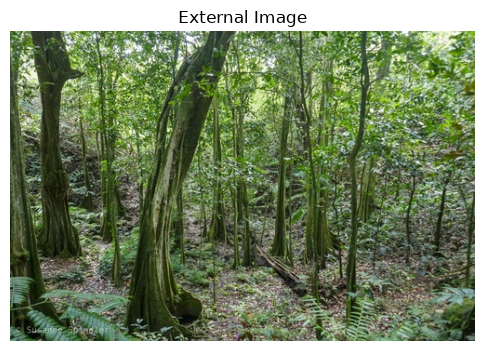


PREDICTION RESULT
Prediction : tree
Confidence : 100.00%


In [33]:
# ============================================================
# EXTERNAL IMAGE PREDICTION + DISPLAY IMAGE
# ============================================================

from PIL import Image
import torch
from torchvision import transforms
import matplotlib.pyplot as plt


# ------------------------------------------------------------
# 1. Path of external image
# ------------------------------------------------------------

image_path = r"F:\Capstone project\module 1 Tree Check\test_images\real5.jpg"


# ------------------------------------------------------------
# 2. Load image
# ------------------------------------------------------------

image = Image.open(image_path).convert("RGB")

print("Image loaded successfully")
print("Image size:", image.size)


# ------------------------------------------------------------
# 3. DISPLAY ENTERED IMAGE
# ------------------------------------------------------------

plt.figure(figsize=(6, 6))

plt.imshow(image)

plt.title("External Image")

plt.axis("off")

plt.show()


# ------------------------------------------------------------
# 4. Same preprocessing used during validation
# ------------------------------------------------------------

transform = transforms.Compose([
    transforms.Resize((224, 224)),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])


# ------------------------------------------------------------
# 5. Convert image to tensor
# ------------------------------------------------------------

image_tensor = transform(image)

# Add batch dimension
image_tensor = image_tensor.unsqueeze(0)

# Move to GPU/CPU
image_tensor = image_tensor.to(device)


# ------------------------------------------------------------
# 6. Model evaluation
# ------------------------------------------------------------

model.eval()

with torch.no_grad():

    output = model(image_tensor)

    probabilities = torch.softmax(
        output,
        dim=1
    )

    predicted_class = torch.argmax(
        probabilities,
        dim=1
    ).item()


# ------------------------------------------------------------
# 7. Class names
# ------------------------------------------------------------

class_names = train_dataset.classes

predicted_label = class_names[predicted_class]

confidence = (
    probabilities[0][predicted_class].item() * 100
)


# ------------------------------------------------------------
# 8. Result
# ------------------------------------------------------------

print("\n" + "=" * 50)
print("PREDICTION RESULT")
print("=" * 50)

print("Prediction :", predicted_label)
print(f"Confidence : {confidence:.2f}%")

print("=" * 50)